# DTLZ2 Results

In [ ]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 5
NPOP = 1280
NGEN = 500
NOBJ = 5 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz2_segura = partial(benchmarks.dtlz2, obj=NOBJ)
toolbox = build_toolbox(func_dtlz2_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 40
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


[0.0, 1.9649584819990135e-17, 2.753180754350168e-17, 0.01412802060232818, 0.5000000012734822, 0.5000000033957173, 0.49999994589785873, 0.49999999257269817, 0.4999999996177317]
[1.0, 1.0, 1.0, 1.0, 0.5000000006238661, 0.4999999995927866, 0.49999994590440694, 0.4999999926886482, 0.5000000022371177]
[1.0, 1.0, 0.9999999999999999, 0.0, 0.5000011675510481, 0.5000000701713865, 0.4999999395755066, 0.5000000246065629, 0.49999999995955297]
[1.0, 1.0, 0.0, 0.0, 0.500000000646045, 0.4999982095034319, 0.49999994586280855, 0.5000002116501316, 0.5000000008991468]
[1.0, 0.0, 0.0, 3.307146619369416e-17, 0.4999999971361766, 0.49999999924601485, 0.4999999458757455, 0.4999999955712652, 0.5000000003302946]
[0.016148703484206217, 0.0, 0.014172123936576742, 9.301549287712099e-10, 0.6329797780552713, 0.5528561586176137, 0.271981114472947, 0.2146836794434605, 0.5243544283825322]
[1.0, 0.0, 0.9475482142894625, 3.307146619369416e-17, 0.49999998695191655, 0.50000000371529, 0.4999999442674769, 0.5000000061406552,

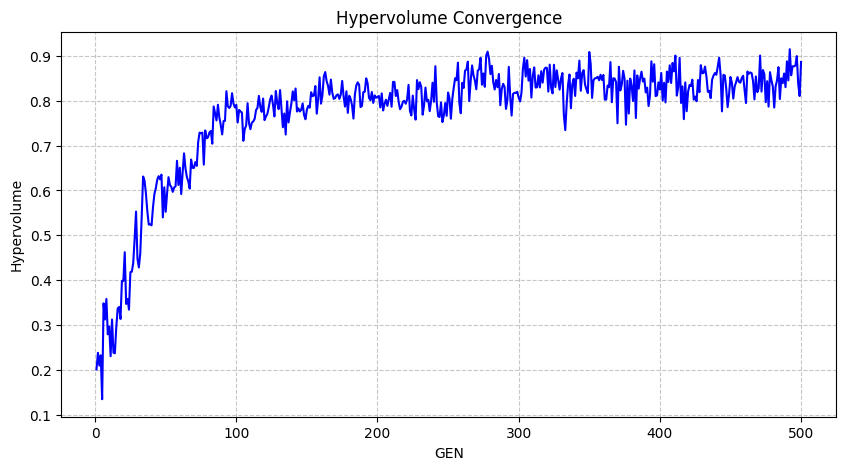

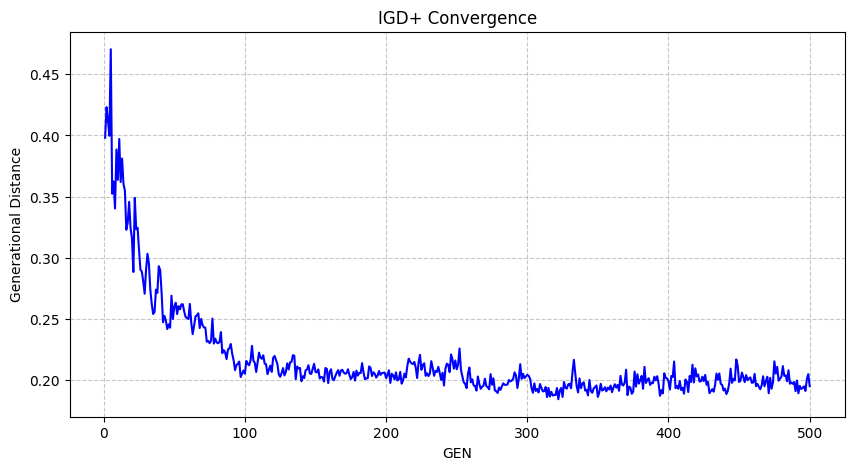

In [2]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
\
# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()